# Catoost

In [10]:
from catboost import CatBoostClassifier
from sklearn.svm import SVC
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
import pandas as pd
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score

import joblib
import optuna

import matplotlib.pyplot as plt
import seaborn as sns

In [11]:
seed = 42

In [12]:
dataset = pd.read_csv("./datasets/thyroid0387_balanced.data", sep = ";", index_col="Unnamed: 0")

In [13]:
dataset.head()

,age,on_thyroxine,query_on_thyroxine,on_antithyroid_medication,sick,pregnant,thyroid_surgery,I131_treatment,query_hypothyroid,query_hyperthyroid,...,T4U_value,FTI_value,TBG_value,ref_STMW,ref_SVHC,ref_SVHD,ref_SVI,ref_WEST,ref_other,diagnosis_group
0,29.0,False,False,False,False,False,False,False,True,False,...,0.964407,110.901257,32.308245,False,False,False,False,False,True,normal
1,29.0,False,False,False,False,False,False,False,False,False,...,0.972645,133.325191,21.728779,False,False,False,False,False,True,normal
2,41.0,False,False,False,False,False,False,False,False,True,...,0.776130,122.989623,11.000000,False,False,False,False,False,True,normal
3,36.0,False,False,False,False,False,False,False,False,False,...,1.015283,107.444888,26.000000,False,False,False,False,False,True,normal
4,32.0,False,False,False,False,False,False,False,False,False,...,0.818433,120.404426,36.000000,False,False,False,False,False,True,misc


In [14]:
dataset["diagnosis_group"].value_counts()

diagnosis_group
normal                   6446
misc                     6446
hypothyroid              6446
hyperthyroid             6446
binding_protein          6446
replacement_therapy      6446
general_health           6446
antithyroid_treatment    6446
Name: count, dtype: int64

In [15]:
label = LabelEncoder()
dataset["diagnosis_group"] = label.fit_transform(dataset["diagnosis_group"])

print(f"{dict(enumerate(label.classes_))}")

{0: 'antithyroid_treatment', 1: 'binding_protein', 2: 'general_health', 3: 'hyperthyroid', 4: 'hypothyroid', 5: 'misc', 6: 'normal', 7: 'replacement_therapy'}


In [ ]:
x = dataset.drop(columns=["diagnosis_group"])
y = dataset["diagnosis_group"]

In [17]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.3, random_state = seed)

In [18]:
print(f"X train: {x_train.shape}\nX test: {x_test.shape}\nY train: {y_train.shape}\nY test: {y_test.shape}")

X train: (36097, 28)
X test: (15471, 28)
Y train: (36097,)
Y test: (15471,)


## Model

In [19]:
cat = CatBoostClassifier()
cat.fit(x_train, y_train)

y_pred = cat.predict(x_test)

Learning rate set to 0.095007
0:	learn: 1.6114153	total: 224ms	remaining: 3m 43s
1:	learn: 1.3423197	total: 258ms	remaining: 2m 8s
2:	learn: 1.1544692	total: 297ms	remaining: 1m 38s
3:	learn: 1.0118181	total: 328ms	remaining: 1m 21s
4:	learn: 0.8981830	total: 377ms	remaining: 1m 14s
5:	learn: 0.8043116	total: 420ms	remaining: 1m 9s
6:	learn: 0.7273281	total: 444ms	remaining: 1m 2s
7:	learn: 0.6563929	total: 478ms	remaining: 59.3s
8:	learn: 0.5996875	total: 504ms	remaining: 55.5s
9:	learn: 0.5447610	total: 543ms	remaining: 53.7s
10:	learn: 0.5001333	total: 574ms	remaining: 51.6s
11:	learn: 0.4606328	total: 610ms	remaining: 50.2s
12:	learn: 0.4265499	total: 653ms	remaining: 49.6s
13:	learn: 0.3949648	total: 707ms	remaining: 49.8s
14:	learn: 0.3667299	total: 768ms	remaining: 50.5s
15:	learn: 0.3419954	total: 815ms	remaining: 50.2s
16:	learn: 0.3171301	total: 845ms	remaining: 48.8s
17:	learn: 0.2985723	total: 875ms	remaining: 47.7s
18:	learn: 0.2787089	total: 908ms	remaining: 46.9s
19:	lea

## Model evaluation

Accuracy: 0.9989658069937302
F1 score: 0.9989644649982147


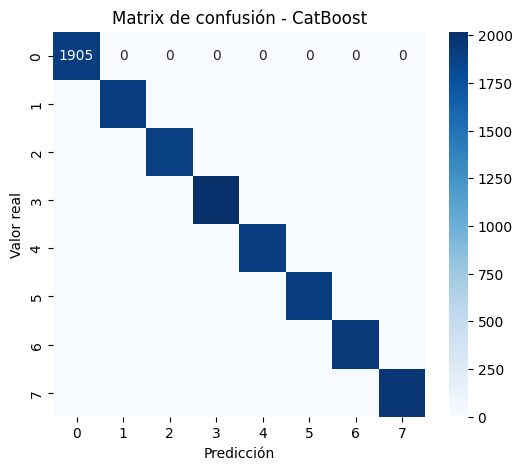

In [20]:
print(f"Accuracy: {accuracy_score(y_test, y_pred)}")
print(f"F1 score: {f1_score(y_test, y_pred, average = 'weighted')}")

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
            
plt.xlabel('Predicción')
plt.ylabel('Valor real')
plt.title('Matrix de confusión - CatBoost')
plt.show()


## Saving model

In [21]:
cat.save_model("./models_saved/catboost.json")

## Bayesian optimization

Function that will be used during the optimization

In [24]:
def objective(trial):
    params = {
        "iterations": trial.suggest_int("iterations", 50, 100),
        "depth": trial.suggest_int("depth", 3, 10),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.5),
        "bagging_temperature": trial.suggest_float("bagging_temperature", 0.0, 1.0),
        "l2_leaf_reg": trial.suggest_float("l2_leaf_reg", 1.0, 10.0),

        "random_state": seed,
        "verbose": 0,
        "random_state": seed,
        "loss_function": "MultiClass",
    }

    model = CatBoostClassifier(**params)
    model.fit(x_train, y_train)

    y_pred = model.predict(x_test)

    return f1_score(y_test, y_pred, average = "weighted")

Optimization process

In [25]:
optimization = optuna.create_study(direction = "maximize")
optimization.optimize(objective, n_trials = 100)

[I 2025-04-18 20:07:57,078] A new study created in memory with name: no-name-e473837f-395c-4d77-992d-fdced377f9cb
[I 2025-04-18 20:08:11,504] Trial 0 finished with value: 0.9983815451130802 and parameters: {'iterations': 86, 'depth': 10, 'learning_rate': 0.10370497247988886, 'bagging_temperature': 0.05218810656270345, 'l2_leaf_reg': 1.6277230997300043}. Best is trial 0 with value: 0.9983815451130802.
[I 2025-04-18 20:08:16,793] Trial 1 finished with value: 0.9895704455159919 and parameters: {'iterations': 51, 'depth': 9, 'learning_rate': 0.025016922459376274, 'bagging_temperature': 0.4933162960132855, 'l2_leaf_reg': 8.70581519317027}. Best is trial 0 with value: 0.9983815451130802.
[I 2025-04-18 20:08:19,013] Trial 2 finished with value: 0.9971514043704349 and parameters: {'iterations': 73, 'depth': 5, 'learning_rate': 0.4620496660213364, 'bagging_temperature': 0.05102390155598835, 'l2_leaf_reg': 9.170242595533159}. Best is trial 0 with value: 0.9983815451130802.
[I 2025-04-18 20:08:23

In [26]:
print(f"Best parameters: {optimization.best_params}")

Best parameters: {'iterations': 100, 'depth': 10, 'learning_rate': 0.2343567905490799, 'bagging_temperature': 0.08906428585721171, 'l2_leaf_reg': 1.0088287474800914}


In [27]:
cat = CatBoostClassifier(**optimization.best_params)
cat.fit(x_train, y_train)

y_pred = cat.predict(x_test)

0:	learn: 0.8671634	total: 163ms	remaining: 16.1s
1:	learn: 0.6081226	total: 328ms	remaining: 16.1s
2:	learn: 0.4533843	total: 510ms	remaining: 16.5s
3:	learn: 0.3454564	total: 665ms	remaining: 16s
4:	learn: 0.2724581	total: 809ms	remaining: 15.4s
5:	learn: 0.2165477	total: 963ms	remaining: 15.1s
6:	learn: 0.1732372	total: 1.11s	remaining: 14.8s
7:	learn: 0.1396352	total: 1.27s	remaining: 14.6s
8:	learn: 0.1144710	total: 1.44s	remaining: 14.6s
9:	learn: 0.0939924	total: 1.6s	remaining: 14.4s
10:	learn: 0.0780388	total: 1.75s	remaining: 14.1s
11:	learn: 0.0665186	total: 1.91s	remaining: 14s
12:	learn: 0.0580256	total: 2.09s	remaining: 14s
13:	learn: 0.0493211	total: 2.24s	remaining: 13.8s
14:	learn: 0.0427993	total: 2.41s	remaining: 13.7s
15:	learn: 0.0369935	total: 2.59s	remaining: 13.6s
16:	learn: 0.0316258	total: 2.74s	remaining: 13.4s
17:	learn: 0.0280348	total: 2.88s	remaining: 13.1s
18:	learn: 0.0253135	total: 3.05s	remaining: 13s
19:	learn: 0.0224483	total: 3.21s	remaining: 12.9s

In [28]:
print(f"Accuracy: {accuracy_score(y_test, y_pred)}")
print(f"F1 score: {f1_score(y_test, y_pred, average = 'weighted')}")

Accuracy: 0.9990304440566221
F1 score: 0.9990294277623992


In [29]:
cat.save_model("./models_saved/catboost_opt.json")